In [1]:
# File handling
import os

# Data manipulation
import numpy as np
import pandas as pd
import polars as pl

# Plotting
import matplotlib.pyplot as plt

# Curve fitting and statistics
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr

# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Smoothing
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
def trim_by_percentile(df, col="confidence", lower=1, upper=99):
    """Remove extreme values within each adjusted_rank group based on percentiles."""
    
    # Apply trimming within each rank group
    def _trim(group):
        # Compute lower and upper percentile thresholds
        low, high = np.percentile(group[col], [lower, upper])
        
        # Keep only values within the percentile range
        return group[(group[col] >= low) & (group[col] <= high)]
    
    # Group by adjusted_rank and apply trimming
    return df.groupby("adjusted_rank", group_keys=False).apply(_trim)

In [3]:
# Path to folder
folder = "data/all_perturb_confidence_scores"

# List all parquet files A.parquet, B.parquet, ... Z.parquet
parquet_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".parquet")]

# Read and select only desired columns efficiently
dfs = []
for f in sorted(parquet_files):
    df = pl.read_parquet(f, columns=["adjusted_rank", "gene", "confidence"])
    dfs.append(df)

# Concatenate all
combined_df = pl.concat(dfs)

# Convert to pandas for plotting
pdf = df.to_pandas()

In [4]:
# Read in MAVE data mapped to GI* data from STARMAP
sc = pd.read_csv('data/all_regions_gi_mave_scores.csv')

# Read in max scores for all proteins
pr = pd.read_csv('data/all_proteins_max_score_matrix_cleaned.csv',index_col=0)

In [5]:
# For each protein, keep the row with the highest score
collapsed = sc.loc[sc.groupby("protein")["score"].idxmax()].reset_index(drop=True)

# Add the top score per protein to the main dataframe
pdf = pdf.merge(
    collapsed[["protein", "score"]],
    how="left",
    left_on="gene",
    right_on="protein"
)

# Compute max value across all TRNs for each protein
max = pd.DataFrame(pr.max(axis=1))
max = max.reset_index()

# Merge max TRN score into main dataframe
pdf = pdf.merge(
    max,
    how="left",
    left_on="gene",
    right_on="Unnamed: 0"
)

# Keep only proteins with strong TRN signal
sub = pdf[pdf[0] > 0.614]

In [6]:
# Keep only genes that have more than 450 TRNs
valid_genes = (
    sub.groupby("gene")["adjusted_rank"]
    .nunique()
    .loc[lambda x: x >= 450]   
    .index
)

# Filter the dataframe
sub2 = sub[sub["gene"].isin(valid_genes)].copy()

# Scale within each gene
sub2["scaled_rank"] = sub2.groupby("gene")["adjusted_rank"].transform(
    lambda x: 500 * (x - x.min()) / (x.max() - x.min())
)

# Apply trimming
cleaned = trim_by_percentile(sub2, col="confidence", lower=5, upper=90)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


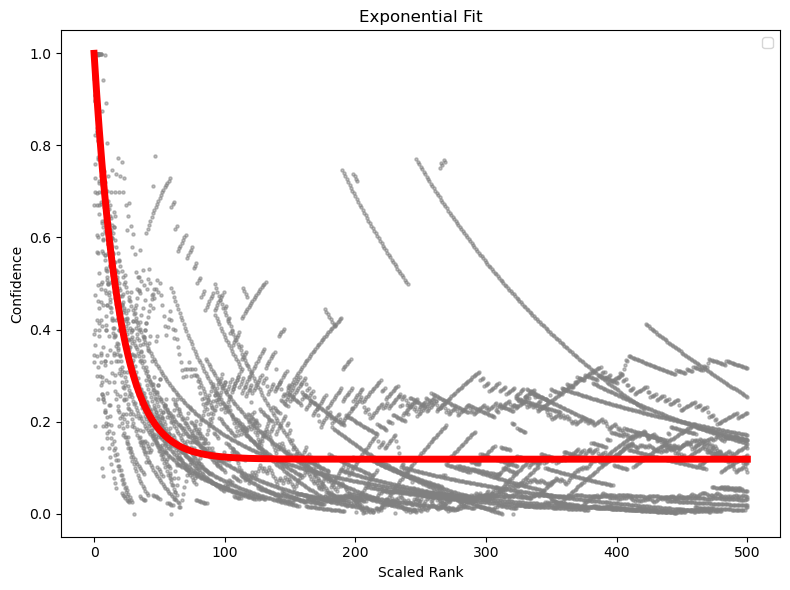

Parameters: a=0.8816, b=-5.2510e-02
Pearson=0.572 (p=0.000e+00)


In [7]:
# Data
x = cleaned["scaled_rank"].values
y = cleaned["confidence"].values

# Exponential model 
def exp_func_fixed(x, a, b):
    return 1 + a * (np.exp(b * x) - 1)

# Apply LOWESS smooting
smoothed = lowess(y, x, frac=0.1) 
x_smooth, y_smooth = smoothed[:, 0], smoothed[:, 1]

# Fit curve using smoothed points
popt, _ = curve_fit(exp_func_fixed, x_smooth, y_smooth, p0=(1, -0.001), maxfev=10000)
y_pred = exp_func_fixed(x, *popt)

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
pcc, p_pcc = pearsonr(y, y_pred)
spearman_corr, p_spear = spearmanr(y, y_pred)

# Generate smooth line for plotting
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = exp_func_fixed(x_fit, *popt)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(x, y, s=5, alpha=0.5, color="grey")
plt.plot(
    x_fit, y_fit,
    color="red", linewidth=5,
)
plt.xlabel("Scaled Rank")
plt.ylabel("Confidence")
plt.title("Exponential Fit")
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

# Print summary
print(f"Parameters: a={popt[0]:.4f}, b={popt[1]:.4e}")
print(f"Pearson={pcc:.3f} (p={p_pcc:.3e})")